<a href="https://colab.research.google.com/github/pardeepkaur-cs/insider-threat-detection-ml/blob/main/insider_threat_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insider Threat Detection System (Unsupervised ML)

## Objective
Detect unusual user behavior in healthcare systems using unsupervised machine learning.

## Problem
Insider threats are difficult to detect because users already have access. This project uses anomaly detection to identify abnormal behavior patterns.

## Approach
- Simulated user activity dataset
- Feature analysis (login time, downloads, device, location)
- Unsupervised ML model (Isolation Forest)
- Detection of anomalies

In [ ]:
import pandas as pd

data = {
"login_hour":[9,10,11,9,10,11,8,9,10,11,2,3,1],
"download_MB":[5,6,4,5,7,6,5,6,5,7,200,250,300],
"device":[1,1,1,1,1,1,1,1,1,1,2,2,2],
"location":[0,0,0,0,0,0,0,0,0,0,1,1,1]
}

df = pd.DataFrame(data)

df

,login_hour,download_MB,device,location
0,9,5,1,0
1,10,6,1,0
2,11,4,1,0
3,9,5,1,0
4,10,7,1,0
5,11,6,1,0
6,8,5,1,0
7,9,6,1,0
8,10,5,1,0
9,11,7,1,0


## Anomaly Detection Model
We use Isolation Forest to detect unusual behavior.

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.2)

model.fit(df)

df["anomaly"] = model.predict(df)

df

,login_hour,download_MB,device,location,anomaly
0,9,5,1,0,1
1,10,6,1,0,1
2,11,4,1,0,1
3,9,5,1,0,1
4,10,7,1,0,1
5,11,6,1,0,1
6,8,5,1,0,1
7,9,6,1,0,1
8,10,5,1,0,1
9,11,7,1,0,1


## Result Interpretation

- 1 = Normal behavior  
- -1 = Anomalous (suspicious behavior)

The model identifies users whose behavior significantly differs from normal patterns.
These anomalies may indicate insider threats or unusual system access.

In [ ]:
suspicious = df[df["anomaly"] == -1]

suspicious

,login_hour,download_MB,device,location,anomaly
10,2,200,2,1,-1
11,3,250,2,1,-1
12,1,300,2,1,-1


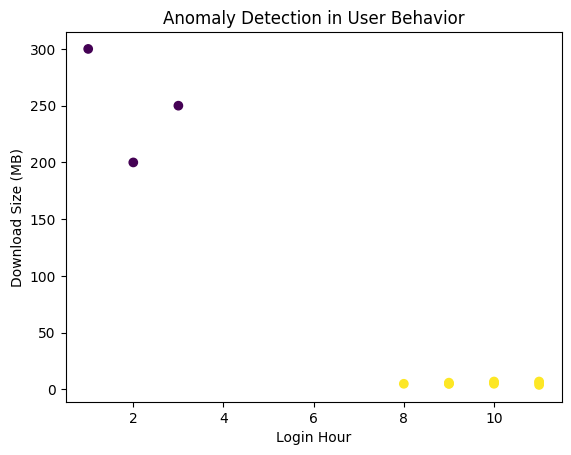

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["login_hour"], df["download_MB"], c=df["anomaly"])

plt.xlabel("Login Hour")
plt.ylabel("Download Size (MB)")
plt.title("Anomaly Detection in User Behavior")

plt.show()

## Research Insight

This project demonstrates how unsupervised machine learning can detect insider threats without prior labeling.

Unlike traditional systems that rely on predefined rules, this approach identifies unusual patterns dynamically.

Such systems are highly relevant in healthcare cybersecurity, where insider threats are difficult to detect using conventional methods.

## Conclusion

The Isolation Forest model successfully identified anomalous user behavior based on login patterns and data access.

This approach provides a scalable method for detecting insider threats in sensitive environments such as healthcare systems.

Future improvements can include:
- Real-time monitoring
- Integration with system logs
- Advanced anomaly detection models